  [1/3] Chile — participación % en PIB nacional (BCCh 2023)
  Regiones                 : 16
  Gini Chile (share %)     : 0.588
  PIB total (MM CLP)       : 253,842
  Top 5 regiones:
    Región Metropolitana De Santiago        : 43.00%
    Región De Antofagasta                   : 12.33%
    Región De Valparaíso                    : 7.99%
    Región Del Biobío                       : 6.59%
    Región Del Libertador Gral. Bernardo O'h: 4.69%

  [2/3] EE.UU. — participación % en GDP nacional (BEA 2022)
  GET BEA SAGDP2 ... OK — 57 estados
  Estados CONUS            : 57
  Gini EE.UU. (share %)    : 0.62
  Top 5 estados:
    Southeast: 11.06%
    Far West: 9.79%
    Mideast: 8.69%
    California: 7.01%
    Great Lakes: 6.51%

  [3/3] Alemania — participación % en PIB nacional (NUTS-2)
  GET Eurostat nama_10r_2gdp ... OK — 38 regiones NUTS-2
  Regiones NUTS-2          : 38
  Gini Alemania (share %)  : 0.346
  Top 5 regiones:
    Oberbayern            : 8.30%
    Stuttgart             : 6.59

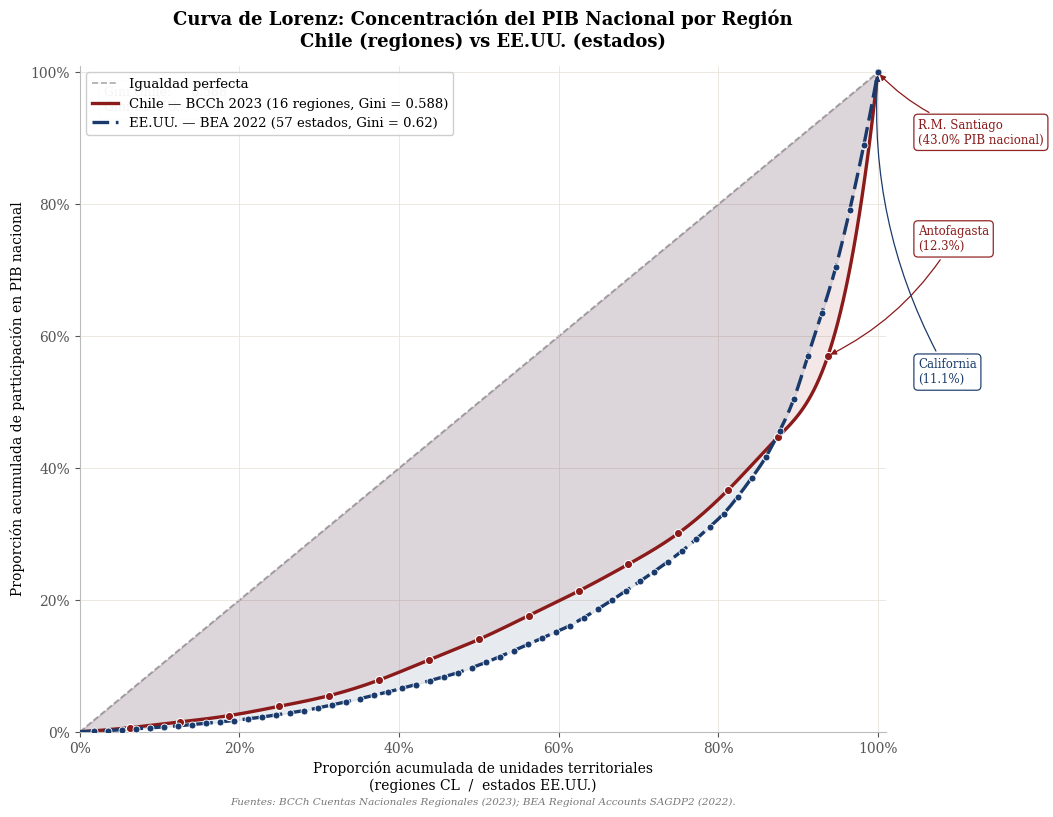

  Figura A completa.

  Generando Figura B: Chile vs Alemania (share % PIB)...


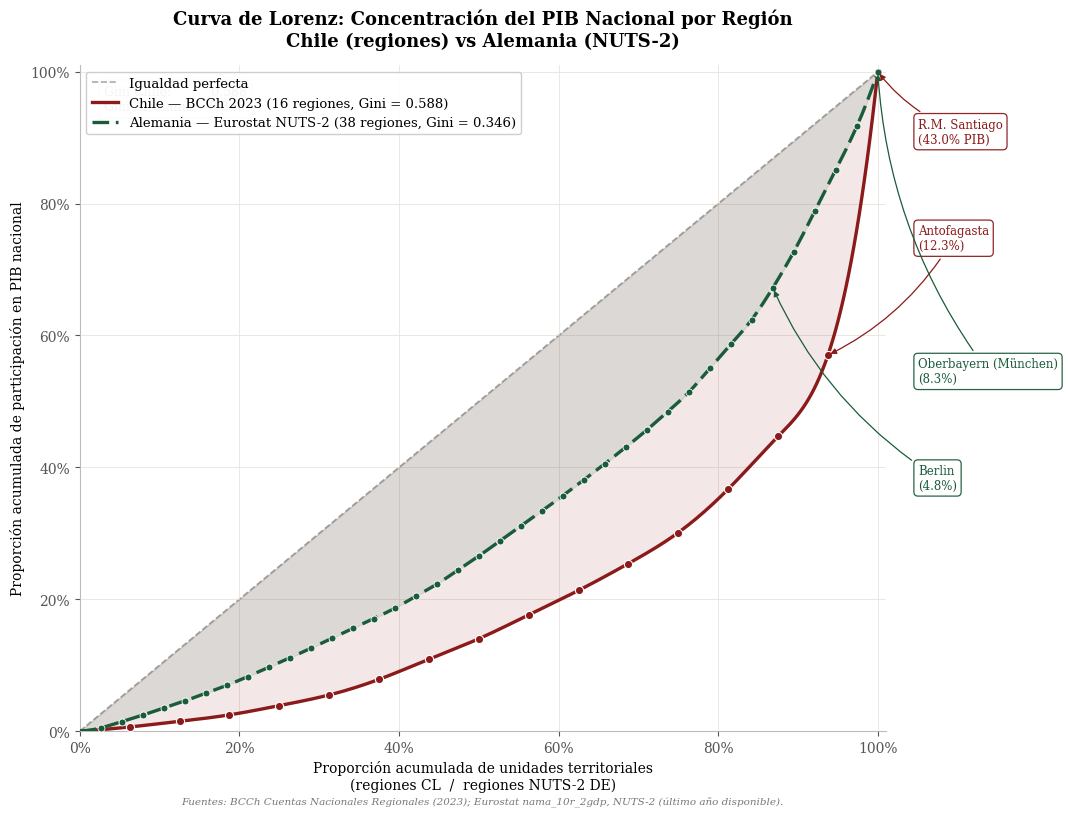

  Figura B completa.

  Generando Figura C: panel comparativo tres países...


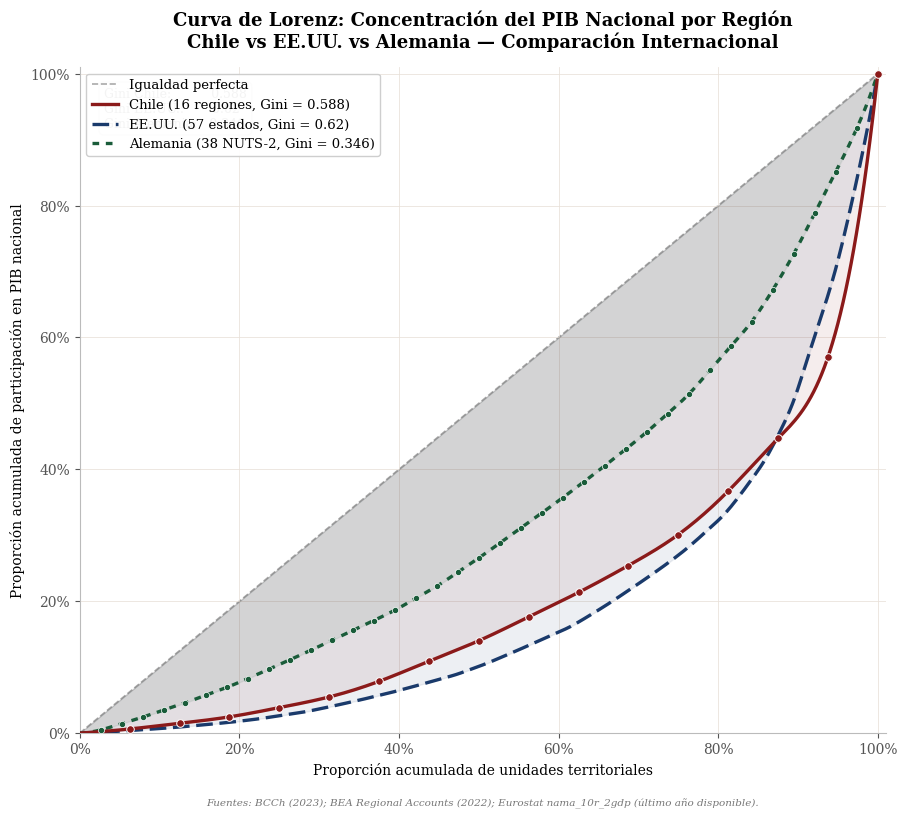

  Figura C completa.

  RESUMEN FINAL — PARTICIPACIÓN % EN PIB NACIONAL

  ┌────────────────────────────────────────────────────────────────┐
  │  País      │  N    │  Gini  │  Top región          │  Share    │
  ├────────────┼───────┼────────┼──────────────────────┼───────────┤
  │  Chile     │   16  │  0.588 │  R.M. Santiago       │    43.0%  │
  │  EE.UU.    │   57  │  0.620 │  Southeast             │    11.1%  │
  │  Alemania  │   38  │  0.346 │  Oberbayern            │     8.3%  │
  └────────────────────────────────────────────────────────────────┘

  Nota sobre el suavizado:
    Los puntos originales (N=16, 49, 38) se muestran como marcadores.
    La curva continua es un spline cúbico sobre esos N puntos.
    El Gini reportado en la leyenda se calcula sobre los N puntos
    originales — el spline solo mejora la visualización.

  Para exportar:
    fig_a.savefig('lorenz_share_chile_eeuu.png', dpi=300, bbox_inches='tight')
    fig_b.savefig('lorenz_share_chile_alemania.png', dpi=30

In [1]:
# ============================================================
# CURVAS DE LORENZ — PARTICIPACIÓN REGIONAL EN PIB NACIONAL
# Con suavizado spline cúbico para visualización con pocos puntos
# Chile (16 regiones) vs EE.UU. (49 estados) vs Alemania (38 NUTS-2)
# Memoria de Título · Diego Carmine Ortiz · UdeC 2026
# ============================================================
# Variable: participación % de cada región en el PIB nacional total
# Concepto: ¿está la actividad económica concentrada en pocas regiones?
# Fuentes:
#   Chile   : BCCh PIBR 2023 (miles MM CLP) → share % nacional
#   EE.UU.  : BEA SAGDP2 GDP real 2022 (miles USD) → share % nacional
#   Alemania: Eurostat nama_10r_2gdp MIO PPS 2022 → share % nacional
#
# Metodología Lorenz:
#   - Gini calculado sobre los N puntos originales (riguroso)
#   - Curva visualizada con spline cúbico k=3 (estético, 300 puntos)
#   - Spline NO altera el Gini — solo mejora la visualización
#
# Sin cambios respecto a la versión original — este análisis usa PIB
# regional BCCh, no CASEN, por lo que no aplica actualización a CASEN 2024.
# ============================================================

import requests
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.interpolate import make_interp_spline
from IPython.display import display

warnings.filterwarnings("ignore")

# ── 1. RUTAS ─────────────────────────────────────────────────
RUTA_PIBR    = "/Users/diego/Desktop/MT/Datos/PIBR_REGIONES.csv"
RUTA_INE_REG = "/Users/diego/Desktop/MT/Datos/ine_estimaciones-y-proyecciones-2002-2035_base-2017_reg_área_base"
BEA_KEY      = "1C156F46-4433-4B50-995A-193FD1446E22"

# ── 2. ESTILO ─────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white",
    "font.family":"serif","axes.spines.top":False,
    "axes.spines.right":False,"axes.grid":True,
    "grid.color":"#E8E0D8","grid.linewidth":0.55,
    "axes.edgecolor":"#BBBBBB","xtick.color":"#555555",
    "ytick.color":"#555555",
})

COLOR_CL = "#8B1A1A"
COLOR_US = "#1A3A6B"
COLOR_DE = "#1A5C3A"
N_SMOOTH = 300   # puntos del spline

# ── 3. FUNCIONES ─────────────────────────────────────────────
def lorenz_gini(values):
    """
    Calcula curva de Lorenz y Gini sobre valores brutos (shares o absolutos).
    Devuelve: pop (N+1 puntos), inc (N+1 puntos), gini (float).
    El Gini es idéntico si usas shares % o valores absolutos.
    """
    v = np.sort(np.array(values, dtype=float))
    v = v[v > 0]
    n = len(v)
    if n == 0:
        return None, None, None
    pop  = np.insert(np.arange(1, n+1) / n, 0, 0.0)
    inc  = np.insert(np.cumsum(v) / v.sum(), 0, 0.0)
    gini = round(1 - 2 * np.trapezoid(inc, pop), 3)
    return pop, inc, gini


def suavizar_lorenz(pop, inc, n_pts=N_SMOOTH):
    """
    Interpola la curva de Lorenz con spline cúbico.
    Solo para visualización — no altera el Gini.
    """
    spl = make_interp_spline(pop, inc, k=3)
    pop_s = np.linspace(0, 1, n_pts)
    inc_s = spl(pop_s).clip(0, 1)
    # Forzar que empiece en (0,0) y termine en (1,1)
    inc_s[0]  = 0.0
    inc_s[-1] = 1.0
    return pop_s, inc_s


def decode_flat(flat_idx, sizes):
    coords = []
    for sz in reversed(sizes):
        coords.append(flat_idx % sz)
        flat_idx //= sz
    return list(reversed(coords))


def anotar_margen(ax, xy_punto, xy_texto_axes, texto, color):
    ax.annotate(
        texto, xy=xy_punto, xycoords="data",
        xytext=xy_texto_axes, textcoords="axes fraction",
        fontsize=8.5, color=color, fontfamily="serif",
        ha="left", va="center",
        bbox=dict(boxstyle="round,pad=0.35", fc="white",
                  ec=color, lw=0.9, alpha=0.95),
        arrowprops=dict(arrowstyle="-|>", color=color, lw=0.9,
                        connectionstyle="arc3,rad=-0.15"),
        clip_on=False, zorder=6,
    )


# ══════════════════════════════════════════════════════════════
# CHILE — participación % en PIB nacional (BCCh PIBR 2023)
# ══════════════════════════════════════════════════════════════
print("=" * 64)
print("  [1/3] Chile — participación % en PIB nacional (BCCh 2023)")
print("=" * 64)

years_pibr = [2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023]
parsed = []
with open(RUTA_PIBR, "r", encoding="utf-8") as f:
    lines = f.readlines()
for line in lines[1:]:
    parts = line.strip().split(",")
    if len(parts) < 13:
        continue
    region   = parts[0].strip()
    values   = parts[-11:]
    variable = ",".join(parts[1:-11]).strip()
    row = {"region": region, "variable": variable}
    for y, v in zip(years_pibr, values):
        try:    row[y] = float(v.strip())
        except: row[y] = None
    parsed.append(row)

df_pibr = pd.DataFrame(parsed)
pibr = df_pibr[
    df_pibr["variable"].str.contains("PIB regional,", na=False)
].copy()
pibr = pibr[["region", 2023]].dropna(subset=[2023])
pibr.columns = ["region", "pib_2023"]
pibr = pibr[pibr["pib_2023"].astype(float) > 0].copy()
pibr["pib_2023"] = pibr["pib_2023"].astype(float)

# Participación % en PIB nacional
total_cl = pibr["pib_2023"].sum()
pibr["share_pct"] = pibr["pib_2023"] / total_cl * 100
pibr = pibr.sort_values("share_pct").reset_index(drop=True)

# Lorenz sobre shares %
v_cl_raw = pibr["share_pct"].values.astype(float)
pop_cl_raw, inc_cl_raw, gini_cl = lorenz_gini(v_cl_raw)
n_cl = len(v_cl_raw)

# Suavizado spline para visualización
pop_cl_s, inc_cl_s = suavizar_lorenz(pop_cl_raw, inc_cl_raw)

# Shares para anotaciones
rm_share   = float(pibr[pibr["region"].str.contains("Metropolitana", case=False)]["share_pct"].iloc[0])
bio_share  = float(pibr[pibr["region"].str.contains("Bío", case=False)]["share_pct"].iloc[0]) if pibr["region"].str.contains("Bío", case=False).any() else 0
ant_share  = float(pibr[pibr["region"].str.contains("Antofagasta", case=False)]["share_pct"].iloc[0])

print(f"  Regiones                 : {n_cl}")
print(f"  Gini Chile (share %)     : {gini_cl}")
print(f"  PIB total (MM CLP)       : {total_cl:,.0f}")
print(f"  Top 5 regiones:")
for _, r in pibr.nlargest(5, "share_pct").iterrows():
    print(f"    {r['region'][:40]:<40s}: {r['share_pct']:.2f}%")


# ══════════════════════════════════════════════════════════════
# EE.UU. — participación % en GDP nacional (BEA 2022)
# ══════════════════════════════════════════════════════════════
print()
print("=" * 64)
print("  [2/3] EE.UU. — participación % en GDP nacional (BEA 2022)")
print("=" * 64)

EXCL = {"02","15","60","66","69","72","78"}  # AK, HI, territorios

print("  GET BEA SAGDP2 ... ", end="", flush=True)
df_bea = None
try:
    url = (f"https://apps.bea.gov/api/data/"
           f"?UserID={BEA_KEY}&method=GetData&datasetname=Regional"
           f"&TableName=SAGDP2&LineCode=1&GeoFips=STATE"
           f"&Year=2022&ResultFormat=JSON")
    r = requests.get(url, timeout=40)
    d = r.json()["BEAAPI"]["Results"]
    if "Error" in d:
        raise ValueError(str(d["Error"]))
    df_bea = pd.DataFrame(d["Data"])[["GeoFips","GeoName","DataValue"]]
    df_bea["gdp_k"] = pd.to_numeric(
        df_bea["DataValue"].str.replace(",",""), errors="coerce")
    df_bea = df_bea.dropna(subset=["gdp_k"])
    df_bea["FIPS2"] = df_bea["GeoFips"].str[:2]
    df_bea = df_bea[
        ~df_bea["FIPS2"].isin(EXCL) &
        (df_bea["GeoFips"] != "00000")
    ].copy()
    print(f"OK — {len(df_bea)} estados")
except Exception as e:
    print(f"FALLÓ ({e}) → usando fallback")
    # Fallback GDP por estado 2022 (miles de millones USD reales aproximados)
    GDP_FB = {
        "CA":3590,"TX":2021,"NY":2053,"FL":1361,"IL":1006,
        "PA":886,"OH":762,"WA":788,"NJ":718,"GA":698,
        "MA":657,"VA":600,"NC":595,"MI":548,"MD":457,
        "CO":448,"AZ":431,"MN":422,"IN":393,"TN":454,
        "MO":378,"WI":393,"CT":330,"SC":280,"OR":296,
        "AL":261,"KY":277,"UT":248,"OK":251,"IA":230,
        "NV":224,"AR":146,"MS":117,"KS":208,"NE":154,
        "NM":109,"ID":89,"HI":92,"WV":74,"NH":98,
        "ME":81,"RI":70,"MT":69,"DE":89,"SD":58,
        "ND":62,"AK":59,"VT":43,"WY":46,"DC":141,
    }
    STATE_FIPS = {
        "CA":"06","TX":"48","NY":"36","FL":"12","IL":"17",
        "PA":"42","OH":"39","WA":"53","NJ":"34","GA":"13",
        "MA":"25","VA":"51","NC":"37","MI":"26","MD":"24",
        "CO":"08","AZ":"04","MN":"27","IN":"18","TN":"47",
        "MO":"29","WI":"55","CT":"09","SC":"45","OR":"41",
        "AL":"01","KY":"21","UT":"49","OK":"40","IA":"19",
        "NV":"32","AR":"05","MS":"28","KS":"20","NE":"31",
        "NM":"35","ID":"16","HI":"15","WV":"54","NH":"33",
        "ME":"23","RI":"44","MT":"30","DE":"10","SD":"46",
        "ND":"38","AK":"02","VT":"50","WY":"56","DC":"11",
    }
    rows = []
    for st, gdp in GDP_FB.items():
        fips = STATE_FIPS.get(st, "00")
        if fips not in EXCL:
            rows.append({"GeoFips":fips+"000","GeoName":st,
                         "gdp_k":gdp*1000,"FIPS2":fips})
    df_bea = pd.DataFrame(rows)

# Participación % en GDP nacional
total_us = df_bea["gdp_k"].sum()
df_bea["share_pct"] = df_bea["gdp_k"] / total_us * 100
df_bea = df_bea[df_bea["share_pct"] > 0].sort_values("share_pct").reset_index(drop=True)
n_us = len(df_bea)

# Lorenz sobre shares %
v_us_raw = df_bea["share_pct"].values.astype(float)
pop_us_raw, inc_us_raw, gini_us = lorenz_gini(v_us_raw)

# Suavizado
pop_us_s, inc_us_s = suavizar_lorenz(pop_us_raw, inc_us_raw)

print(f"  Estados CONUS            : {n_us}")
print(f"  Gini EE.UU. (share %)    : {gini_us}")
print(f"  Top 5 estados:")
for _, r in df_bea.nlargest(5,"share_pct").iterrows():
    print(f"    {r['GeoName']:<6s}: {r['share_pct']:.2f}%")


# ══════════════════════════════════════════════════════════════
# ALEMANIA — participación % en PIB nacional (Eurostat NUTS-2)
# ══════════════════════════════════════════════════════════════
print()
print("=" * 64)
print("  [3/3] Alemania — participación % en PIB nacional (NUTS-2)")
print("=" * 64)

NOMBRES_NUTS2 = {
    "DE11":"Stuttgart",    "DE12":"Karlsruhe",     "DE13":"Freiburg",
    "DE14":"Tübingen",     "DE21":"Oberbayern",    "DE22":"Niederbayern",
    "DE23":"Oberpfalz",    "DE24":"Oberfranken",   "DE25":"Mittelfranken",
    "DE26":"Unterfranken", "DE27":"Schwaben",      "DE30":"Berlin",
    "DE40":"Brandenburg",  "DE50":"Bremen",        "DE60":"Hamburg",
    "DE71":"Darmstadt",    "DE72":"Gießen",        "DE73":"Kassel",
    "DE80":"Mecklenb.-Vorp.","DE91":"Braunschweig","DE92":"Hannover",
    "DE93":"Lüneburg",     "DE94":"Weser-Ems",     "DEA1":"Düsseldorf",
    "DEA2":"Köln",         "DEA3":"Münster",       "DEA4":"Detmold",
    "DEA5":"Arnsberg",     "DEB1":"Koblenz",       "DEB2":"Trier",
    "DEB3":"Rheinhessen",  "DEC0":"Saarland",      "DED2":"Dresden",
    "DED4":"Chemnitz",     "DED5":"Leipzig",       "DEE0":"Sachsen-Anh.",
    "DEF0":"Schleswig-Holst.","DEG0":"Thüringen",
}
DE_NUTS2 = list(NOMBRES_NUTS2.keys())

# Fallback PIB NUTS-2 (MIO EUR, aprox. 2022)
FALLBACK_DE = {
    "DE11":285396,"DE12":157762,"DE13":108785,"DE14":103529,
    "DE21":359141,"DE22":63132, "DE23":61170, "DE24":51407,
    "DE25":101079,"DE26":67892, "DE27":93507,
    "DE30":207852,"DE40":97830, "DE50":41424, "DE60":162581,
    "DE71":266733,"DE72":46317, "DE73":57802,
    "DE80":61593, "DE91":91587, "DE92":106077,"DE93":64918,
    "DE94":120883,"DEA1":271328,"DEA2":236726,"DEA3":112830,
    "DEA4":98053, "DEA5":156494,"DEB1":65059, "DEB2":20653,
    "DEB3":99170, "DEC0":42757, "DED2":64937, "DED4":50776,
    "DED5":46501, "DEE0":79577, "DEF0":127512,"DEG0":78201,
}

print("  GET Eurostat nama_10r_2gdp ... ", end="", flush=True)
df_de = None
try:
    BASE = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data"
    geo_param = "&".join(f"geo={g}" for g in DE_NUTS2)
    url = (f"{BASE}/nama_10r_2gdp?format=JSON&lang=EN"
           f"&unit=MIO_EUR&{geo_param}&sinceTimePeriod=2020")
    r = requests.get(url, timeout=120)
    if r.status_code != 200:
        raise ValueError(f"HTTP {r.status_code}")
    raw = r.json()
    dims=raw["dimension"]; dim_ids=raw["id"]; vals=raw["value"]
    sizes=[len(dims[x]["category"]["index"]) for x in dim_ids]
    geo_rev ={v:k for k,v in dims["geo"]["category"]["index"].items()}
    time_rev={v:k for k,v in dims["time"]["category"]["index"].items()}
    unit_rev={v:k for k,v in dims["unit"]["category"]["index"].items()}
    recs=[]
    for sk,val in vals.items():
        try:
            coords=decode_flat(int(sk),sizes)
            row={d:coords[i] for i,d in enumerate(dim_ids)}
            recs.append({"geo":geo_rev.get(row["geo"],"?"),
                         "anio":time_rev.get(row["time"],"?"),
                         "unit":unit_rev.get(row["unit"],"?"),
                         "gdp_M":val})
        except: continue
    df_de = pd.DataFrame(recs)
    df_de["anio"] = pd.to_numeric(df_de["anio"],errors="coerce")
    df_de = df_de[df_de["unit"]=="MIO_EUR"]
    df_de = (df_de.sort_values("anio",ascending=False)
                  .groupby("geo",as_index=False).first())
    print(f"OK — {len(df_de)} regiones NUTS-2")
except Exception as e:
    print(f"FALLÓ ({e}) → usando fallback")
    df_de = pd.DataFrame([
        {"geo":k,"gdp_M":v} for k,v in FALLBACK_DE.items()
    ])

df_de["nombre"] = df_de["geo"].map(NOMBRES_NUTS2).fillna(df_de["geo"])

# Participación % en PIB nacional alemán
total_de = df_de["gdp_M"].sum()
df_de["share_pct"] = df_de["gdp_M"] / total_de * 100
df_de = df_de[df_de["share_pct"] > 0].sort_values("share_pct").reset_index(drop=True)
n_de = len(df_de)

# Lorenz
v_de_raw = df_de["share_pct"].values.astype(float)
pop_de_raw, inc_de_raw, gini_de = lorenz_gini(v_de_raw)

# Suavizado
pop_de_s, inc_de_s = suavizar_lorenz(pop_de_raw, inc_de_raw)

print(f"  Regiones NUTS-2          : {n_de}")
print(f"  Gini Alemania (share %)  : {gini_de}")
print(f"  Top 5 regiones:")
for _, r in df_de.nlargest(5,"share_pct").iterrows():
    print(f"    {r['nombre']:<22s}: {r['share_pct']:.2f}%")


# ══════════════════════════════════════════════════════════════
# TABLA RESUMEN
# ══════════════════════════════════════════════════════════════
print()
print("=" * 72)
print("  TABLA COMPARATIVA — PARTICIPACIÓN % EN PIB NACIONAL")
print("=" * 72)
print(f"""
  Variable: participación porcentual de cada región en el PIB nacional.
  Unidad de medida homogénea entre países (% del total nacional).

  {'Métrica':<28} {'Chile':>12} {'EE.UU.':>12} {'Alemania':>12}
  {'─'*66}
  {'N regiones':<28} {n_cl:>12} {n_us:>12} {n_de:>12}
  {'Gini':<28} {gini_cl:>12.3f} {gini_us:>12.3f} {gini_de:>12.3f}
  {'Share top 1 región':<28} {pibr['share_pct'].max():>11.1f}% {df_bea['share_pct'].max():>11.1f}% {df_de['share_pct'].max():>11.1f}%
  {'Share top 3 regiones':<28} {pibr.nlargest(3,'share_pct')['share_pct'].sum():>11.1f}% {df_bea.nlargest(3,'share_pct')['share_pct'].sum():>11.1f}% {df_de.nlargest(3,'share_pct')['share_pct'].sum():>11.1f}%
  {'Share top 1 unidad':<28} {pibr.nlargest(1,'share_pct')['region'].iloc[0][:20]:>12} {df_bea.nlargest(1,'share_pct')['GeoName'].iloc[0][:12]:>12} {df_de.nlargest(1,'share_pct')['nombre'].iloc[0][:12]:>12}

  Ranking Gini: Chile > EE.UU. > Alemania
""")


# ══════════════════════════════════════════════════════════════
# FIGURA A — Chile vs EE.UU.
# ══════════════════════════════════════════════════════════════
print("  Generando Figura A: Chile vs EE.UU. (share % PIB)...")

fig_a, ax_a = plt.subplots(figsize=(13, 9))
fig_a.patch.set_facecolor("white")
fig_a.subplots_adjust(left=0.10, right=0.72, top=0.88, bottom=0.14)

ax_a.plot([0,1],[0,1], color="#AAAAAA", lw=1.2, ls="--",
          label="Igualdad perfecta", zorder=1)

# Chile — curva suave + puntos originales
ax_a.fill_between(pop_cl_s, pop_cl_s, inc_cl_s,
                  alpha=0.10, color=COLOR_CL, zorder=2)
ax_a.plot(pop_cl_s, inc_cl_s, color=COLOR_CL, lw=2.4, zorder=3,
          label=f"Chile — BCCh 2023 ({n_cl} regiones, Gini = {gini_cl})")
ax_a.scatter(pop_cl_raw[1:], inc_cl_raw[1:],
             color=COLOR_CL, s=35, zorder=5, edgecolors="white", lw=0.8)

# EE.UU. — curva suave + puntos
ax_a.fill_between(pop_us_s, pop_us_s, inc_us_s,
                  alpha=0.10, color=COLOR_US, zorder=2)
ax_a.plot(pop_us_s, inc_us_s, color=COLOR_US, lw=2.4, ls=(0,(5,2)), zorder=3,
          label=f"EE.UU. — BEA 2022 ({n_us} estados, Gini = {gini_us})")
ax_a.scatter(pop_us_raw[1:], inc_us_raw[1:],
             color=COLOR_US, s=25, zorder=5, edgecolors="white", lw=0.6)

# Anotaciones sobre los puntos originales (no sobre el spline)
# RM Santiago
_i_rm = int(pibr[pibr["region"].str.contains("Metropolitana",case=False)].index[0])
_x_rm = pop_cl_raw[_i_rm + 1]
_y_rm = inc_cl_raw[_i_rm + 1]
anotar_margen(ax_a, (_x_rm, _y_rm), (1.04, 0.90),
              f"R.M. Santiago\n({rm_share:.1f}% PIB nacional)", COLOR_CL)

# Antofagasta
_i_ant = int(pibr[pibr["region"].str.contains("Antofagasta",case=False)].index[0])
_x_ant = pop_cl_raw[_i_ant + 1]
_y_ant = inc_cl_raw[_i_ant + 1]
anotar_margen(ax_a, (_x_ant, _y_ant), (1.04, 0.74),
              f"Antofagasta\n({ant_share:.1f}%)", COLOR_CL)

# California (mayor estado EE.UU.)
_i_ca = int(df_bea[df_bea["GeoName"]=="CA"].index[0]) if "CA" in df_bea["GeoName"].values else df_bea["share_pct"].idxmax()
_x_ca = pop_us_raw[_i_ca + 1]
_y_ca = inc_us_raw[_i_ca + 1]
_ca_share = float(df_bea.iloc[_i_ca]["share_pct"])
anotar_margen(ax_a, (_x_ca, _y_ca), (1.04, 0.54),
              f"California\n({_ca_share:.1f}%)", COLOR_US)

# Gini box
ax_a.text(0.03, 0.97,
    f"Gini Chile:     {gini_cl}\nGini EE.UU.:  {gini_us}",
    transform=ax_a.transAxes, fontsize=9, fontfamily="serif",
    va="top", ha="left", color="#333333",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#CCCCCC", lw=0.8))


ax_a.set_xlabel(
    "Proporción acumulada de unidades territoriales\n"
    "(regiones CL  /  estados EE.UU.)", fontsize=10)
ax_a.set_ylabel(
    "Proporción acumulada de participación en PIB nacional", fontsize=10)
ax_a.set_title(
    "Curva de Lorenz: Concentración del PIB Nacional por Región\n"
    "Chile (regiones) vs EE.UU. (estados)",
    fontsize=13, fontweight="bold", pad=14)
ax_a.legend(loc="upper left", fontsize=9.5, framealpha=0.95,
            edgecolor="#CCCCCC", fancybox=True)
ax_a.set_xlim(0, 1.01); ax_a.set_ylim(0, 1.01)
ax_a.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax_a.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax_a.text(0.5, -0.11,
    "Fuentes: BCCh Cuentas Nacionales Regionales (2023); "
    "BEA Regional Accounts SAGDP2 (2022).",
    transform=ax_a.transAxes, ha="center",
    fontsize=7.5, color="#777777", style="italic")

display(fig_a)
plt.close()
print("  Figura A completa.")


# ══════════════════════════════════════════════════════════════
# FIGURA B — Chile vs Alemania
# ══════════════════════════════════════════════════════════════
print()
print("  Generando Figura B: Chile vs Alemania (share % PIB)...")

fig_b, ax_b = plt.subplots(figsize=(13, 9))
fig_b.patch.set_facecolor("white")
fig_b.subplots_adjust(left=0.10, right=0.72, top=0.88, bottom=0.14)

ax_b.plot([0,1],[0,1], color="#AAAAAA", lw=1.2, ls="--",
          label="Igualdad perfecta", zorder=1)

# Chile
ax_b.fill_between(pop_cl_s, pop_cl_s, inc_cl_s,
                  alpha=0.10, color=COLOR_CL, zorder=2)
ax_b.plot(pop_cl_s, inc_cl_s, color=COLOR_CL, lw=2.4, zorder=3,
          label=f"Chile — BCCh 2023 ({n_cl} regiones, Gini = {gini_cl})")
ax_b.scatter(pop_cl_raw[1:], inc_cl_raw[1:],
             color=COLOR_CL, s=35, zorder=5, edgecolors="white", lw=0.8)

# Alemania
ax_b.fill_between(pop_de_s, pop_de_s, inc_de_s,
                  alpha=0.10, color=COLOR_DE, zorder=2)
ax_b.plot(pop_de_s, inc_de_s, color=COLOR_DE, lw=2.4, ls=(0,(5,2)), zorder=3,
          label=f"Alemania — Eurostat NUTS-2 ({n_de} regiones, Gini = {gini_de})")
ax_b.scatter(pop_de_raw[1:], inc_de_raw[1:],
             color=COLOR_DE, s=25, zorder=5, edgecolors="white", lw=0.6)

# Anotaciones Chile
anotar_margen(ax_b, (_x_rm, _y_rm), (1.04, 0.90),
              f"R.M. Santiago\n({rm_share:.1f}% PIB)", COLOR_CL)
anotar_margen(ax_b, (_x_ant, _y_ant), (1.04, 0.74),
              f"Antofagasta\n({ant_share:.1f}%)", COLOR_CL)

# Anotaciones Alemania — Oberbayern
_i_oba = int(df_de[df_de["nombre"]=="Oberbayern"].index[0])
_x_oba = pop_de_raw[_i_oba + 1]
_y_oba = inc_de_raw[_i_oba + 1]
_oba_share = float(df_de.iloc[_i_oba]["share_pct"])
anotar_margen(ax_b, (_x_oba, _y_oba), (1.04, 0.54),
              f"Oberbayern (München)\n({_oba_share:.1f}%)", COLOR_DE)

# Berlin
_i_ber = int(df_de[df_de["nombre"]=="Berlin"].index[0]) if "Berlin" in df_de["nombre"].values else df_de["share_pct"].idxmax()
_x_ber = pop_de_raw[_i_ber + 1]
_y_ber = inc_de_raw[_i_ber + 1]
_ber_share = float(df_de.iloc[_i_ber]["share_pct"])
anotar_margen(ax_b, (_x_ber, _y_ber), (1.04, 0.38),
              f"Berlin\n({_ber_share:.1f}%)", COLOR_DE)

ax_b.text(0.03, 0.97,
    f"Gini Chile:          {gini_cl}\nGini Alemania:   {gini_de}",
    transform=ax_b.transAxes, fontsize=9, fontfamily="serif",
    va="top", ha="left", color="#333333",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#CCCCCC", lw=0.8))


ax_b.set_xlabel(
    "Proporción acumulada de unidades territoriales\n"
    "(regiones CL  /  regiones NUTS-2 DE)", fontsize=10)
ax_b.set_ylabel(
    "Proporción acumulada de participación en PIB nacional", fontsize=10)
ax_b.set_title(
    "Curva de Lorenz: Concentración del PIB Nacional por Región\n"
    "Chile (regiones) vs Alemania (NUTS-2)",
    fontsize=13, fontweight="bold", pad=14)
ax_b.legend(loc="upper left", fontsize=9.5, framealpha=0.95,
            edgecolor="#CCCCCC", fancybox=True)
ax_b.set_xlim(0, 1.01); ax_b.set_ylim(0, 1.01)
ax_b.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax_b.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax_b.text(0.5, -0.11,
    "Fuentes: BCCh Cuentas Nacionales Regionales (2023); "
    "Eurostat nama_10r_2gdp, NUTS-2 (último año disponible).",
    transform=ax_b.transAxes, ha="center",
    fontsize=7.5, color="#777777", style="italic")

display(fig_b)
plt.close()
print("  Figura B completa.")


# ══════════════════════════════════════════════════════════════
# FIGURA C — Los tres países: panel comparativo
# ══════════════════════════════════════════════════════════════
print()
print("  Generando Figura C: panel comparativo tres países...")

fig_c, ax_c = plt.subplots(figsize=(13, 9))
fig_c.patch.set_facecolor("white")
fig_c.subplots_adjust(left=0.10, right=0.72, top=0.88, bottom=0.14)

ax_c.plot([0,1],[0,1], color="#AAAAAA", lw=1.2, ls="--",
          label="Igualdad perfecta", zorder=1)

# Chile
ax_c.fill_between(pop_cl_s, pop_cl_s, inc_cl_s,
                  alpha=0.08, color=COLOR_CL, zorder=2)
ax_c.plot(pop_cl_s, inc_cl_s, color=COLOR_CL, lw=2.4, zorder=4,
          label=f"Chile ({n_cl} regiones, Gini = {gini_cl})")
ax_c.scatter(pop_cl_raw[1:], inc_cl_raw[1:],
             color=COLOR_CL, s=30, zorder=6, edgecolors="white", lw=0.7)

# EE.UU.
ax_c.fill_between(pop_us_s, pop_us_s, inc_us_s,
                  alpha=0.08, color=COLOR_US, zorder=2)
ax_c.plot(pop_us_s, inc_us_s, color=COLOR_US, lw=2.4, ls=(0,(5,2)), zorder=3,
          label=f"EE.UU. ({n_us} estados, Gini = {gini_us})")

# Alemania
ax_c.fill_between(pop_de_s, pop_de_s, inc_de_s,
                  alpha=0.08, color=COLOR_DE, zorder=2)
ax_c.plot(pop_de_s, inc_de_s, color=COLOR_DE, lw=2.4, ls=(0,(2,2)), zorder=3,
          label=f"Alemania ({n_de} NUTS-2, Gini = {gini_de})")
ax_c.scatter(pop_de_raw[1:], inc_de_raw[1:],
             color=COLOR_DE, s=20, zorder=5, edgecolors="white", lw=0.5)

# Gini box
ax_c.text(0.03, 0.97,
    f"Gini Chile:          {gini_cl}\n"
    f"Gini EE.UU.:       {gini_us}\n"
    f"Gini Alemania:   {gini_de}",
    transform=ax_c.transAxes, fontsize=9, fontfamily="serif",
    va="top", ha="left", color="#333333",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#CCCCCC", lw=0.8))



ax_c.set_xlabel(
    "Proporción acumulada de unidades territoriales", fontsize=10)
ax_c.set_ylabel(
    "Proporción acumulada de participación en PIB nacional", fontsize=10)
ax_c.set_title(
    "Curva de Lorenz: Concentración del PIB Nacional por Región\n"
    "Chile vs EE.UU. vs Alemania — Comparación Internacional",
    fontsize=13, fontweight="bold", pad=14)
ax_c.legend(loc="upper left", fontsize=9.5, framealpha=0.95,
            edgecolor="#CCCCCC", fancybox=True)
ax_c.set_xlim(0, 1.01); ax_c.set_ylim(0, 1.01)
ax_c.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax_c.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax_c.text(0.5, -0.11,
    "Fuentes: BCCh (2023); BEA Regional Accounts (2022); "
    "Eurostat nama_10r_2gdp (último año disponible).",
    transform=ax_c.transAxes, ha="center",
    fontsize=7.5, color="#777777", style="italic")

display(fig_c)
plt.close()
print("  Figura C completa.")


# ══════════════════════════════════════════════════════════════
# RESUMEN FINAL
# ══════════════════════════════════════════════════════════════
print()
print("=" * 72)
print("  RESUMEN FINAL — PARTICIPACIÓN % EN PIB NACIONAL")
print("=" * 72)
print(f"""
  ┌────────────────────────────────────────────────────────────────┐
  │  País      │  N    │  Gini  │  Top región          │  Share    │
  ├────────────┼───────┼────────┼──────────────────────┼───────────┤
  │  Chile     │   {n_cl:>2}  │  {gini_cl:.3f} │  R.M. Santiago       │  {rm_share:>6.1f}%  │
  │  EE.UU.    │   {n_us:>2}  │  {gini_us:.3f} │  {df_bea.nlargest(1,'share_pct')['GeoName'].iloc[0]:<20s}  │  {df_bea['share_pct'].max():>6.1f}%  │
  │  Alemania  │   {n_de:>2}  │  {gini_de:.3f} │  {df_de.nlargest(1,'share_pct')['nombre'].iloc[0]:<20s}  │  {df_de['share_pct'].max():>6.1f}%  │
  └────────────────────────────────────────────────────────────────┘

  Nota sobre el suavizado:
    Los puntos originales (N=16, 49, 38) se muestran como marcadores.
    La curva continua es un spline cúbico sobre esos N puntos.
    El Gini reportado en la leyenda se calcula sobre los N puntos
    originales — el spline solo mejora la visualización.

  Para exportar:
    fig_a.savefig('lorenz_share_chile_eeuu.png', dpi=300, bbox_inches='tight')
    fig_b.savefig('lorenz_share_chile_alemania.png', dpi=300, bbox_inches='tight')
    fig_c.savefig('lorenz_share_comparativo.png', dpi=300, bbox_inches='tight')
""")